# Telco Customer Churn Analysis
## An End-to-End ETL + Machine Learning Pipeline

**Author:** Prakhar Sharma  
**Dataset:** IBM Telco Customer Churn (7,043 customers)  
**Tools:** Python, pandas, SQLite, SQLAlchemy, scikit-learn, XGBoost, seaborn

---

### Project Overview
This project simulates a real-world data pipeline for a telecom company experiencing customer churn.
The goal is to identify which customers are at risk of leaving and why - enabling the business to intervene proactively.

The pipeline consists of three stages:
1. **Extract** - Load raw CRM data from CSV
2. **Transform** - Clean, encode, and engineer features
3. **Load** - Persist both raw and transformed data into a SQLite database

Exploratory analysis and a machine learning model are then built on top of this foundation.

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from pathlib import Path

# Database path
DB_PATH = Path(os.getcwd()).parent / "data" / "churn.db"
if not DB_PATH.exists():
    DB_PATH = Path(os.getcwd()) / "data" / "churn.db"

print(f"DB path: {DB_PATH}")
print(f"DB file exists: {os.path.exists(DB_PATH)}")

# Load from database
engine = create_engine(f"sqlite:///{DB_PATH}")
df = pd.read_sql("SELECT * FROM customers", engine)
df_raw = pd.read_sql("SELECT * FROM raw_customers", engine)

print(f"Loaded {len(df)} rows and {len(df.columns)} columns")
df.head()

DB path: c:\Users\prakh\OneDrive\Desktop\Projects\Python Data Analysis Project\data\churn.db
DB file exists: True
Loaded 7043 rows and 33 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,charges_per_tenure,is_long_term,is_high_spender
0,0,0,1,0,1,0,NaN,1,29.85,29.85,...,0,0,0,0,0,1,0,29.850000,0,0
1,1,0,0,0,34,1,0.0,0,56.95,1889.50,...,0,0,1,0,0,0,1,55.573529,1,0
2,1,0,0,0,2,1,0.0,1,53.85,108.15,...,0,0,0,0,0,0,1,54.075000,0,0
3,1,0,0,0,45,0,NaN,0,42.30,1840.75,...,0,0,1,0,0,0,0,40.905556,1,0
4,0,0,0,0,2,1,0.0,1,70.70,151.65,...,0,0,0,0,0,1,0,75.825000,0,1


## Exploratory Data Analysis

Before building a model, we need to understand the data. The following analysis answers
three business questions:

1. How many customers are churning and what does the overall rate look like?
2. What customer attributes are most associated with churn?
3. Which features will likely matter most for prediction?

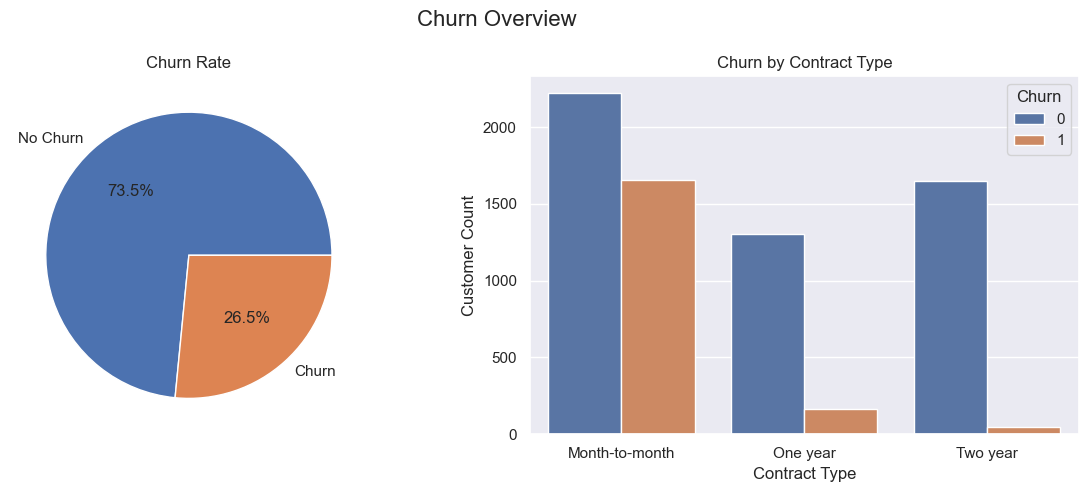

In [2]:
# Set visual style
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Churn Overview", fontsize=16)

# Chart 1: Churn distribution
churn_counts = df_raw["Churn"].value_counts()
axes[0].pie(churn_counts, labels=["No Churn", "Churn"], autopct="%1.1f%%", colors=["#4C72B0", "#DD8452"])
axes[0].set_title("Churn Rate")

# Chart 2: Churn by contract type
sns.countplot(data=df_raw, x="Contract", hue="Churn", ax=axes[1])
axes[1].set_title("Churn by Contract Type")
axes[1].set_xlabel("Contract Type")
axes[1].set_ylabel("Customer Count")

plt.tight_layout()
plt.show()

### Key Finding 1 — Churn Rate & Contract Type
**26.5% of customers churned** — a significant business problem worth solving.

Contract type is the single strongest visual predictor:
- Month-to-month customers churn at nearly a **1:1 ratio** with those who stay
- One year contract customers churn at roughly **1:9**
- Two year contract customers almost never churn

**Business implication:** Incentivizing customers to commit to longer contracts would likely have the highest impact on reducing churn.

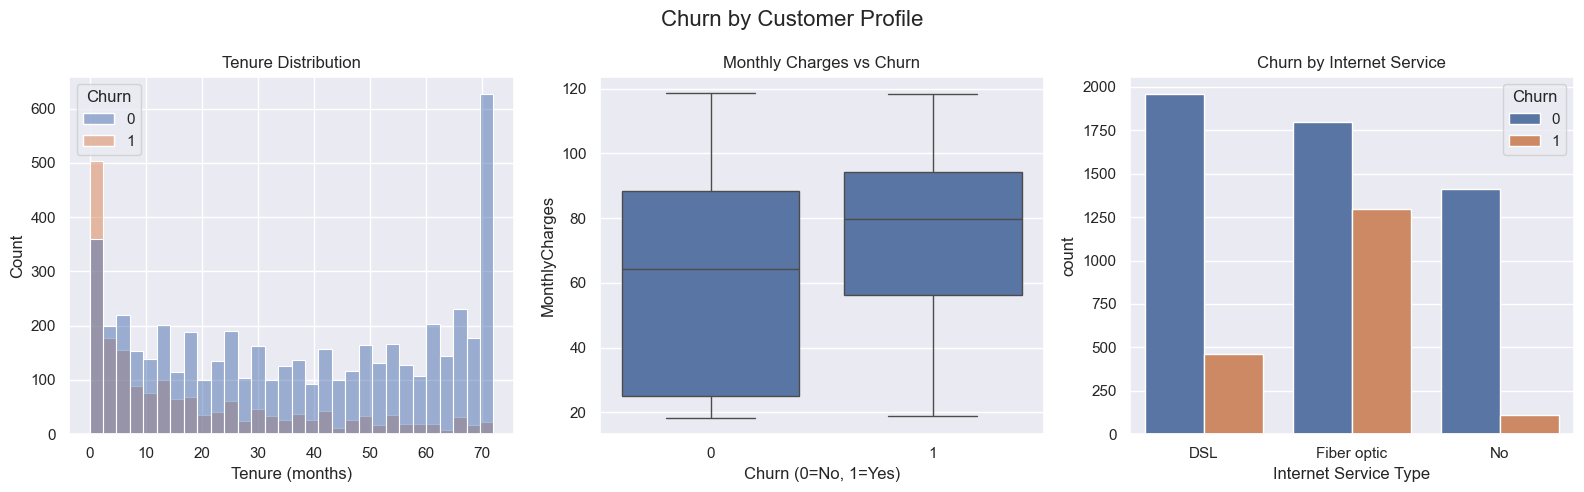

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Churn by Customer Profile", fontsize=16)

# Chart 1: Tenure distribution by churn
sns.histplot(data=df_raw, x="tenure", hue="Churn", bins=30, ax=axes[0])
axes[0].set_title("Tenure Distribution")
axes[0].set_xlabel("Tenure (months)")

# Chart 2: Monthly charges by churn
sns.boxplot(data=df_raw, x="Churn", y="MonthlyCharges", ax=axes[1])
axes[1].set_title("Monthly Charges vs Churn")
axes[1].set_xlabel("Churn (0=No, 1=Yes)")

# Chart 3: Churn by internet service
sns.countplot(data=df_raw, x="InternetService", hue="Churn", ax=axes[2])
axes[2].set_title("Churn by Internet Service")
axes[2].set_xlabel("Internet Service Type")

plt.tight_layout()
plt.show()

### Key Finding 2 - Tenure, Charges & Internet Service
Three more patterns emerge clearly:

- **New customers are the highest risk** - churn is heavily concentrated in the first 10 months. Customers who stay beyond 24 months rarely leave.
- **Higher monthly charges correlate with churn** - churned customers pay measurably more on average, suggesting price sensitivity is a factor.
- **Fiber optic customers churn significantly more than DSL customers** - this may indicate a service quality or value perception issue specific to fiber.

**Business implication:** Onboarding programs targeting new customers in their first year could meaningfully reduce churn.

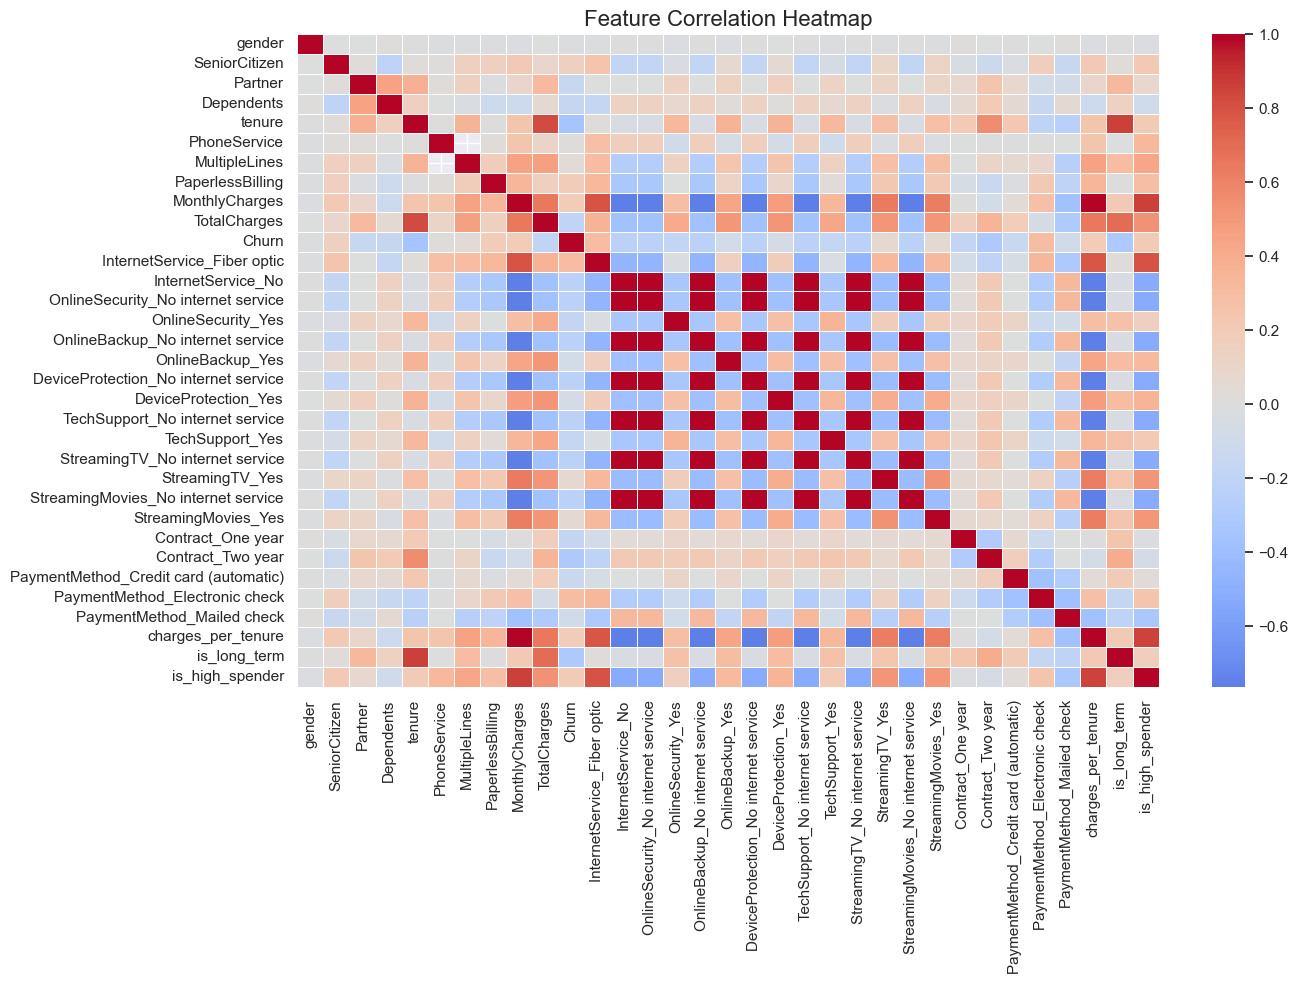

In [4]:
fig, ax = plt.subplots(figsize=(14, 10))

# Only use numeric columns
numeric_df = df.select_dtypes(include="number")

# Compute correlation matrix
corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Feature Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

### Key Finding 3 - Feature Correlations
The correlation heatmap reveals the full relationship structure of the dataset:

- **Tenure** is negatively correlated with churn - longer customers stay longer
- **MonthlyCharges** is positively correlated with churn - higher bills increase risk
- **Fiber optic internet** is positively correlated with churn
- **Longer contracts** are negatively correlated with churn

These findings directly inform feature selection for the machine learning model in the next section.

---